In [ ]:
!pip install networkx -q
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(0)

In [ ]:
channels = ["Fp1", "Fp2", "F3", "O1"]
C = len(channels)

# Sentetik simetrik "bağlantı gücü" matrisi
A = np.array([
    [1.00, 0.80, 0.30, 0.05],
    [0.80, 1.00, 0.25, 0.04],
    [0.30, 0.25, 1.00, 0.15],
    [0.05, 0.04, 0.15, 1.00],
])

print("Simetrik mi?", np.allclose(A, A.T))

Simetrik mi? True


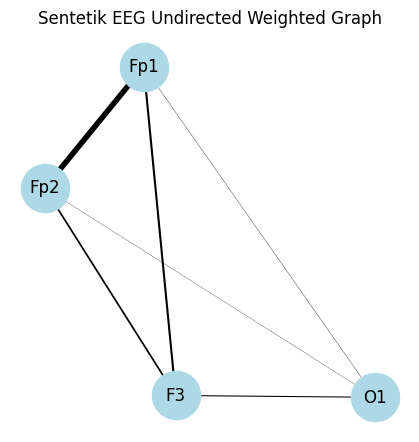

In [ ]:
G = nx.from_numpy_array(A)
mapping = {i: ch for i, ch in enumerate(channels)}
G = nx.relabel_nodes(G, mapping)

# Diagonal'i (self-loop) çizimden çıkaralım
G.remove_edges_from(nx.selfloop_edges(G))

pos = nx.spring_layout(G, seed=1)
weights = [G[u][v]['weight']*5 for u,v in G.edges()]

plt.figure(figsize=(4,4))
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=1200, width=weights)
plt.title("Sentetik EEG Undirected Weighted Graph")
plt.show()

Simetrik mi? False


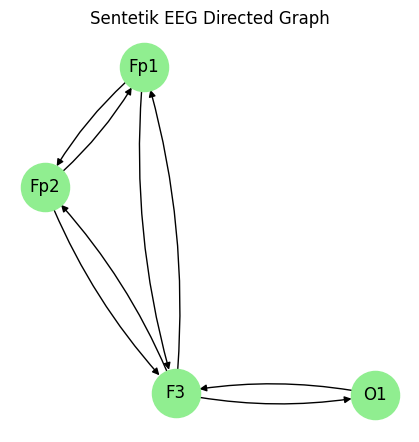

In [ ]:
A_dir = np.array([
    [1.0, 0.1, 0.4, 0.0],
    [0.05,1.0, 0.2, 0.0],
    [0.02,0.03,1.0, 0.3],
    [0.0, 0.0, 0.01,1.0],
])
print("Simetrik mi?", np.allclose(A_dir, A_dir.T))

G_dir = nx.from_numpy_array(A_dir, create_using=nx.DiGraph)
G_dir = nx.relabel_nodes(G_dir, mapping)
G_dir.remove_edges_from(nx.selfloop_edges(G_dir))

plt.figure(figsize=(4,4))
nx.draw(G_dir, pos, with_labels=True, node_color='lightgreen',
        node_size=1200, arrows=True, connectionstyle='arc3,rad=0.1')
plt.title("Sentetik EEG Directed Graph")
plt.show()

In [ ]:
assert A.shape == (C, C), "Adjacency matrix boyutu kanal sayısıyla eşleşmiyor!"
assert not np.isnan(A).any(), "Adjacency matrix içinde NaN var!"
print("Kontroller geçti ✓")

Kontroller geçti ✓
